# Plot and Analyse Monthly Precip Stats

## Load libraries

In [1]:
import sys, os, glob
import numpy as np 
import xarray as xr

import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.pyplot as plt


## Input Data

### Annual Data

In [2]:
indir = '/work/bk1415/b380352/data/ngc4008/overall_precip_stats/'

In [3]:
flist = sorted( glob.glob(f'{indir}/annual_precip_stats_????.nc') )

In [4]:
print(f'... number of files is {len(flist)}')

... number of files is 30


In [5]:
annual = xr.open_mfdataset( flist )

In [6]:
annual.load()

<xarray.Dataset>
Dimensions:                   (rel_contrib_bin: 1000, precip_bin: 10000,
                               year: 30)
Coordinates:
  * rel_contrib_bin           (rel_contrib_bin) float64 0.1 0.2 ... 99.9 100.0
  * precip_bin                (precip_bin) float64 0.1 0.1001 ... 1e+04
  * year                      (year) int64 2020 2021 2022 ... 2047 2048 2049
Data variables:
    relative_counts_all       (year, rel_contrib_bin) float64 nan ... 2.41e-05
    relative_counts_tropics   (year, rel_contrib_bin) float64 nan ... 2.008e-05
    relative_cumsum_all       (year, precip_bin) float64 0.1181 0.1183 ... 100.0
    relative_cumsum_tropics   (year, precip_bin) float64 0.1371 0.1373 ... 100.0
    cumulated_precip_all      (year) float64 8.456e+07 8.332e+07 ... 8.249e+07
    cumulated_precip_tropics  (year) float64 1.087e+07 1.1e+07 ... 1.114e+07
    length_all                (year) float64 nan nan nan ... nan nan nan
    length_tropics            (year) float64 nan nan nan ... nan nan nan

## Plotting - Relative Amount Accumulations

In [7]:
set2 = plt.get_cmap("Set2").colors

colors = {
    '90 %': set2[1],
    '500 mm': set2[3],

    '70 %': set2[0],
    '200 mm': set2[4],

    '50 %': set2[2],
    '80 mm': set2[5],
}

In [8]:
cumsum_all = annual['relative_cumsum_all']
cs_ave = cumsum_all.mean('year')
pbin = cs_ave.precip_bin

thresh = [50,70,90]
cs4thresh = np.interp(thresh, cs_ave,pbin)

In [9]:
cs4thresh

array([ 81.43780478, 206.3691711 , 497.57015572])

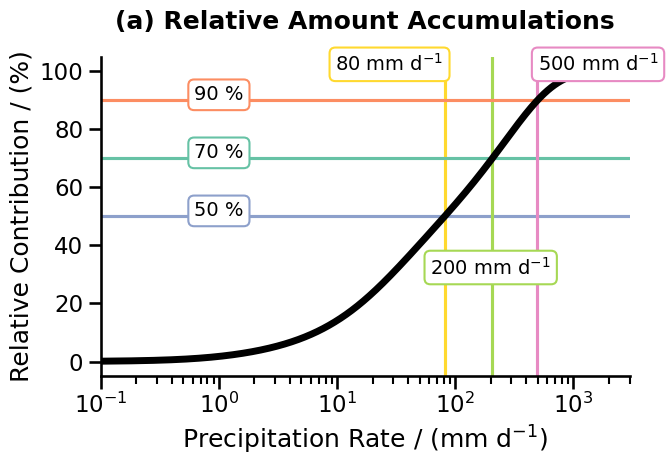

In [37]:
fig, ax = plt.subplots(figsize=(7,5))

# Set color cycle for this axis only
n_years = len(cumsum_all.year)
cmap=plt.cm.RdYlGn_r

# Plot

hcols = [colors['50 %'], colors['70 %'],colors['90 %']]
vcols = [colors['80 mm'], colors['200 mm'],colors['500 mm']]

for i, contrib in enumerate( thresh ):
    ax.axhline( contrib, c = hcols[i])
    ax.axvline( cs4thresh[i], c = vcols[i] )

ax.text(80, 100, '80 mm d${}^{-1}$', ha = 'right', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['80 mm'], boxstyle="round"))
ax.text(200, 30, '200 mm d${}^{-1}$', ha = 'center', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['200 mm'], boxstyle="round"))
ax.text(500, 100, '500 mm d${}^{-1}$', ha = 'left', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['500 mm'], boxstyle="round"))

ax.text(1, 90, '90 %', ha = 'center', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['90 %'], boxstyle="round"))
ax.text(1, 70, '70 %', ha = 'center', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['70 %'], boxstyle="round"))
ax.text(1, 50, '50 %', ha = 'center', fontsize = 14, bbox=dict(facecolor="w", edgecolor=colors['50 %'], boxstyle="round"))

cs_ave.plot(hue = 'year', c = 'k', lw = 5, ax = ax)
ax.set_xscale('log')
ax.set_xlim(1e-1, 3e3)
ax.set_xlabel("Precipitation Rate / (mm d$^{-1}$)")
ax.set_ylabel('Relative Contribution / (%)')

plt.title( '(a) Relative Amount Accumulations', fontweight = 'bold',pad = 20)
sns.despine()
plt.tight_layout()

## Calculation Amount Distributions

### 

In [13]:
conf = {'length_all': 25165824, 'length_tropics': 4195664}

In [14]:
cumsum_precip_all = annual['relative_cumsum_all']/ 100. * annual['cumulated_precip_all']  / conf['length_all']
cumsum_precip_tropics = annual['relative_cumsum_tropics'] / 100. * annual['cumulated_precip_tropics']  / conf['length_tropics']

cumsum_precip_all = cumsum_precip_all.rolling( precip_bin = 121, center = True).mean()
cumsum_precip_tropics = cumsum_precip_tropics.rolling( precip_bin = 121, center = True).mean()

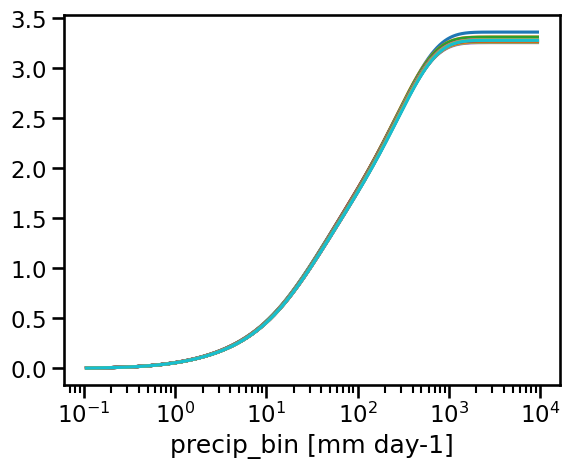

In [15]:
cumsum_precip_all.plot(hue='year', add_legend = False);
plt.xscale('log')

### Amount distribution

In [16]:
# define precip bins
dlnp = np.log( cumsum_precip_all.precip_bin ).diff('precip_bin') 

In [ ]:
dlnp

In [ ]:
# bin cumsum
amount_distrib_all = cumsum_precip_all.diff('precip_bin') / dlnp
amount_distrib_tropics = cumsum_precip_tropics.diff('precip_bin') / dlnp

### Changes in the amount distributions

In [12]:
# define present day and future 
slice1 = dict( year = slice(2026, 2035))
slice2 = dict( year = slice(2041, 2050))
N=10

In [18]:
# amount dsitirbutions for time slices
amount_all1 = amount_distrib_all.sel( **slice1 )
amount_all2 = amount_distrib_all.sel( **slice2 )

amount_trop1 = amount_distrib_tropics.sel( **slice1 )
amount_trop2 = amount_distrib_tropics.sel( **slice2 )


In [19]:
# calculate changes in ampunt distirbutions
ds = xr.Dataset()
ds['precip_rate'] = amount_all1.precip_bin

ds['global_mean'] = amount_all2.mean('year') - amount_all1.mean('year')

ds['tropical_mean'] = amount_trop2.mean('year') - amount_trop1.mean('year')

ds['tropical_std'] = 2/N * np.sqrt( amount_trop1.var('year') + amount_trop2.var('year'))

ds['global_std'] = 2/N * np.sqrt( amount_all1.var('year') + amount_all2.var('year'))

min_amount = 0.001
ref_amount = amount_all1.mean('year')
ref_amount = ref_amount.where( ref_amount > min_amount )

ds['global_mean_relative'] = 100*ds['global_mean'] / ref_amount
ds['global_std_relative'] = 100*ds['global_std'] / ref_amount

min_amount = 0.001
ref_amount = amount_trop1.mean('year')
ref_amount = ref_amount.where( ref_amount > min_amount )

ds['tropical_mean_relative'] = 100*ds['tropical_mean'] / ref_amount
ds['tropical_std_relative'] = 100*ds['tropical_std'] / ref_amount



## Plotting - Amount distributions

### Tropical Belt vs. Global

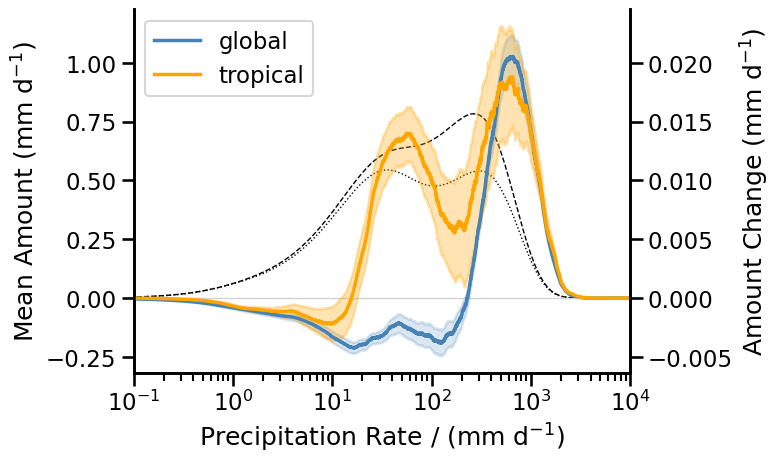

In [20]:
fig, ax1 = plt.subplots(figsize=(8,5))


ax = ax1.twinx()
# Plot shaded uncertainty bands
ax.fill_between(
    ds["precip_rate"],
    ds["global_mean"] - ds["global_std"],
    ds["global_mean"] + ds["global_std"],
    alpha=0.2, color="steelblue"
)
ax.fill_between(
    ds["precip_rate"],
    ds["tropical_mean"] - ds["tropical_std"],
    ds["tropical_mean"] + ds["tropical_std"],
    alpha=0.3, color="orange"
)

# Plot lines
amount_distrib_all.mean('year').plot(ax=ax1, color="black", linewidth=1., linestyle = '--')
amount_distrib_tropics.mean('year').plot(ax=ax1, color="black", linewidth=1., linestyle = ':')

ds["global_mean"].plot(ax=ax, color="steelblue", linewidth=2.5, label="global")
ds["tropical_mean"].plot(ax=ax, color="orange", linewidth=2.5, label="tropical")

# Reference line at y=0
ax.axhline(0, color="lightgray", linewidth=1.0, zorder=0)

# Log x-axis
ax.set_xscale("log")
ax.set_xlim(1e-1, 1e4)

# Axis labels
ax1.set_xlabel("Precipitation Rate / (mm d$^{-1}$)")
ax.set_ylabel("Amount Change (mm d$^{-1}$)")
ax1.set_ylabel("Mean Amount (mm d$^{-1}$)")
ax.legend()#loc="upper right")

y1, y2 = ax.get_ylim()
scale = 50
ax1.set_ylim( scale * y1, scale * y2 )

# Legend

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sns.despine(right = False)
plt.tight_layout()
plt.show()

## Only Global

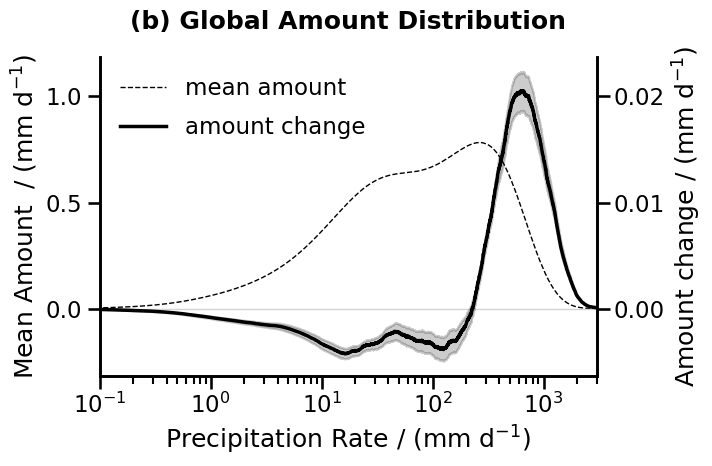

In [35]:
fig, ax1 = plt.subplots(figsize=(8,5))


ax = ax1.twinx()
# Plot shaded uncertainty bands
ax.fill_between(
    ds["precip_rate"],
    ds["global_mean"] - ds["global_std"],
    ds["global_mean"] + ds["global_std"],
    alpha=0.2, color="black"
)

# Plot lines
amount_distrib_all.mean('year').plot(ax=ax1, color="black", linewidth=1., linestyle = '--', label = 'mean amount',)

ds["global_mean"].plot(ax=ax, color="black", linewidth=2.5, label="amount change")

# Reference line at y=0
ax.axhline(0, color="lightgray", linewidth=1.0, zorder=0)

# Log x-axis
ax.set_xscale("log")
ax.set_xlim(1e-1, 3e3)

# Axis labels
ax1.set_xlabel("Precipitation Rate / (mm d$^{-1}$)")
ax.set_ylabel("Amount change / (mm d$^{-1}$)")
ax1.set_ylabel("Mean Amount  / (mm d$^{-1}$)")
ax1.legend(loc="upper left", frameon = False)
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.88), frameon = False)

y1, y2 = ax.get_ylim()
scale = 50.
ax1.set_ylim( scale * y1, scale * y2 )

# Legend

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title( '(b) Amount Contribution', fontweight = 'bold',pad = 20)
sns.despine(right = False)
plt.tight_layout()